In [1]:
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import pickle
import numpy as np

# Define the PyTorch model
class ReconstructImageModel(nn.Module):
    def __init__(self, input_size=32*32, output_size=32*32):
        super(ReconstructImageModel, self).__init__()
        self.fc1 = nn.Linear(input_size, output_size)
        self.sigmoid = nn.Sigmoid()  # For image pixel values between 0 and 1

    def forward(self, x):
        x = self.fc1(x)
        return x

In [ ]:
# Variables

scratch_dir = "/storage/ice1/7/8/jyou79/base_a0.07_pf0.8"
cifar_dir = "/storage/ice1/7/8/jyou79/cifar-10-batches-py-50"
storage_dir = "/storage/ice1/7/8/jyou79"
images = 500

In [3]:
import pickle
import numpy as np

def rgb_to_grayscale(row):
        R = row[:1024].reshape(32, 32)
        G = row[1024:2048].reshape(32, 32)
        B = row[2048:].reshape(32, 32)
        grayscale = 0.299 * R + 0.587 * G + 0.114 * B
        return grayscale
   
with open(f'%s/data_batch_1'%(cifar_dir), 'rb') as f:
        cifar = pickle.load(f, encoding='bytes')

In [4]:
def binning(rates, positions, dimension):
    H, xedges, yedges = np.histogram2d(
        x=positions[:, 0],
        y=positions[:, 1],
        bins=dimension,
        range=[[0, 1], [0, 1]],
        weights=rates
    )
    
    # 2. Count of the neurons in each bin (this time no weights).
    C, _, _ = np.histogram2d(
        x=positions[:, 0],
        y=positions[:, 1],
        bins=dimension,
        range=[[0, 1], [0, 1]]
    )

    with np.errstate(divide='ignore', invalid='ignore'):
        reconstructed = H / C
        reconstructed[np.isnan(reconstructed)] = 0
    
    return reconstructed

In [5]:
import matplotlib.pyplot as plt

img = cifar[0]
plt.imshow(img, cmap='gray')
plt.show()

KeyError: 0

(8000,)


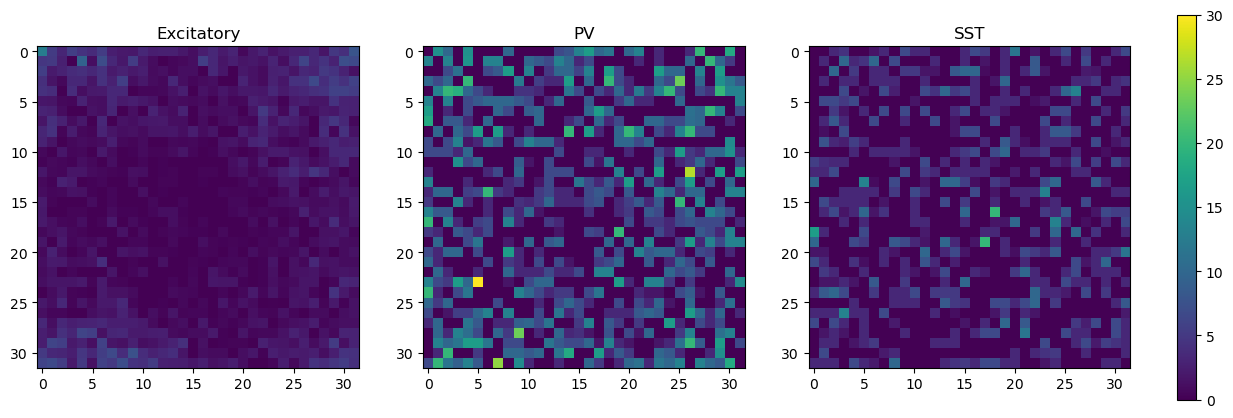

In [7]:
with open(f'%s/results_999/1_positions.pickle'%(scratch_dir), 'rb') as f:
    positions = pickle.load(f, encoding='bytes') 
    
with open(f'%s/results_999/1_rates.pickle'%(scratch_dir), 'rb') as f:
    rates = pickle.load(f, encoding='bytes') 
    
with open(f'%s/results_999/1_spikes.pickle'%(scratch_dir), 'rb') as f:
    spikes = pickle.load(f, encoding='bytes') 

exc_indices = np.arange(1,8000)
pv_indices = np.arange(8000,9000)
sst_indices = np.arange(9000,10000)

exc_rates = np.array(rates[:8000])

print(exc_rates.shape)
pv_rates = np.array(rates[8000:9000])
sst_rates = np.array(rates[9000:])

for i in exc_indices:
    tot = 0
    for j in spikes[i]:
        if j > 200:
            tot += 1
    exc_rates[i] = tot / 300 * 1000

for i in pv_indices:
    tot = 0
    for j in spikes[i]:
        if j > 200:
            tot += 1
    pv_rates[i - 8000] = tot / 300 * 1000
            
for i in sst_indices:
    tot = 0
    for j in spikes[i]:
        if j > 200:
            tot += 1
    sst_rates[i - 9000] = tot / 300 * 1000

exc_positions = np.array(positions[:8000])
pv_positions = np.array(positions[8000:9000])
sst_positions = np.array(positions[9000:])

exc_binned = binning(exc_rates, exc_positions, 32)
pv_binned = binning(pv_rates, pv_positions, 32)
sst_binned = binning(sst_rates, sst_positions, 32)

fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
vmin = min(exc_binned.min(), pv_binned.min(), sst_binned.min())
vmax = max(exc_binned.max(), pv_binned.max(), sst_binned.max())

im0 = axes[0].imshow(exc_binned, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Excitatory')
im1 = axes[1].imshow(pv_binned, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('PV')
im2 = axes[2].imshow(sst_binned, cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title('SST')

fig.colorbar(im0, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
plt.show()

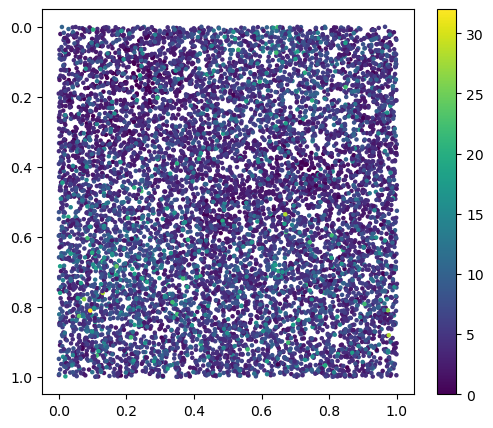

In [8]:
with open(f'%s/results_7/1_positions.pickle'%(scratch_dir), 'rb') as f:
    positions = pickle.load(f, encoding='bytes') 
    
with open(f'%s/results_7/1_rates.pickle'%(scratch_dir), 'rb') as f:
    rates = pickle.load(f, encoding='bytes') 
    
positions = np.array(positions)
rates = np.array(rates)

plt.figure(figsize=(6, 5))
plt.scatter(positions[:, 0], positions[:, 1], c=rates, cmap='viridis', s=5)
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

In [13]:
model = ReconstructImageModel(input_size=32*32*3, output_size=32*32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ReconstructImageModel(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (sigmoid): Sigmoid()
)

In [11]:
train_dataset = []

for i in range(images):
    with open(f'%s/results_{i}/1_positions.pickle'%(scratch_dir), 'rb') as f:
        positions = pickle.load(f, encoding='bytes') 
        
    with open(f'%s/results_{i}/1_rates.pickle'%(scratch_dir), 'rb') as f:
        rates = pickle.load(f, encoding='bytes') 

    exc_rates = np.array(rates[:8000])
    pv_rates = np.array(rates[8000:9000])
    sst_rates = np.array(rates[9000:])

    exc_positions = np.array(positions[:8000])
    pv_positions = np.array(positions[8000:9000])
    sst_positions = np.array(positions[9000:])

    exc_binned = binning(exc_rates, exc_positions, 64)
    pv_binned = binning(pv_rates, pv_positions, 64)
    sst_binned = binning(sst_rates, sst_positions, 64)
    
    binned = np.concatenate((exc_binned, pv_binned, sst_binned)).reshape(-1)
    
    train_dataset.append(binned)
    
train_dataset = np.array(train_dataset) 
train_dataset = torch.tensor(train_dataset, dtype=torch.float)
target_dataset = torch.tensor(cifar[:images].reshape(-1, 32*32), dtype=torch.float)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

lossl = []

num_epochs = 5
model.train()
for epoch in range(num_epochs):
    for i in range(len(train_dataset)):
        optimizer.zero_grad()
        outputs = model(train_dataset[i])
        loss = criterion(outputs, target_dataset[i])
        loss.backward()
        optimizer.step()
        lossl.append(loss.item())
        
plt.plot(lossl)
plt.show()

KeyboardInterrupt: 

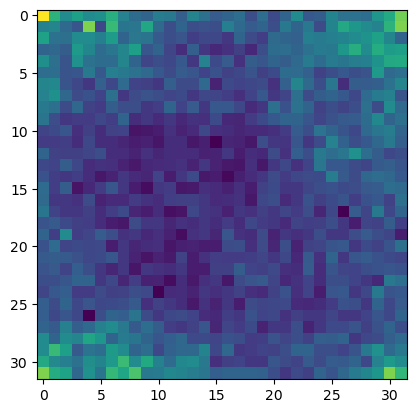

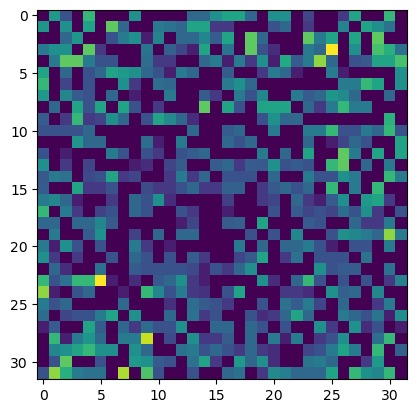

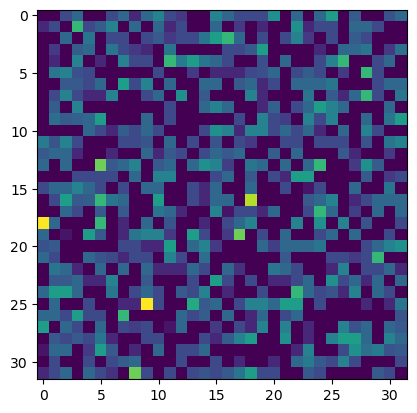

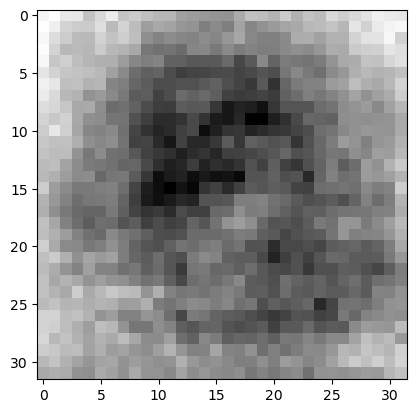

In [19]:
with open(f'%s/results_999/1_positions.pickle'%(scratch_dir), 'rb') as f:
    positions = pickle.load(f, encoding='bytes') 
    
with open(f'%s/results_999/1_rates.pickle'%(scratch_dir), 'rb') as f:
    rates = pickle.load(f, encoding='bytes') 

model = torch.load(f'%s/model.pth'%(scratch_dir), map_location=torch.device('cpu'), weights_only=False)

exc_rates = np.array(rates[:8000])
pv_rates = np.array(rates[8000:9000])
sst_rates = np.array(rates[9000:])

exc_positions = np.array(positions[:8000])
pv_positions = np.array(positions[8000:9000])
sst_positions = np.array(positions[9000:])

exc_binned = binning(exc_rates, exc_positions, 32)
pv_binned = binning(pv_rates, pv_positions, 32)
sst_binned = binning(sst_rates, sst_positions, 32)
    
binned = np.concatenate((exc_binned, pv_binned, sst_binned)).reshape(-1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
binned = torch.tensor(binned, dtype=torch.float).to(device)

model.eval()

reconstructed = model(binned).detach().cpu().numpy().reshape(32, 32)
binned = binned.reshape(3, 32, 32)

for i in range(3):
    plt.imshow(binned[i, :, :])
    plt.show()

plt.imshow(reconstructed, cmap='gray')
plt.show()

In [ ]:
test_dataset = []

for i in range(900, 1000):
    with open(f'%s/results_{i}/1_positions.pickle'%(scratch_dir), 'rb') as f:
        positions = pickle.load(f, encoding='bytes') 
        
    with open(f'%s/results_{i}/1_rates.pickle'%(scratch_dir), 'rb') as f:
        rates = pickle.load(f, encoding='bytes') 

    exc_rates = np.array(rates[:8000])
    pv_rates = np.array(rates[8000:9000])
    sst_rates = np.array(rates[9000:])

    exc_positions = np.array(positions[:8000])
    pv_positions = np.array(positions[8000:9000])
    sst_positions = np.array(positions[9000:])

    exc_binned = binning(exc_rates, exc_positions, 64)
    pv_binned = binning(pv_rates, pv_positions, 64)
    sst_binned = binning(sst_rates, sst_positions, 64)
    
    binned = np.concatenate((exc_binned, pv_binned, sst_binned)).reshape(-1)
    
    test_dataset.append(binned)
    
test_dataset = np.array(test_dataset) 
test_dataset = torch.tensor(test_dataset, dtype=torch.float)
target_dataset = torch.tensor(cifar[900:1000].reshape(-1, 32*32), dtype=torch.float)
model = torch.load(f'%s/model.pth'%(scratch_dir), map_location=torch.device('cpu'), weights_only=False)
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

lossl = []
total = 0

for i in range(len(test_dataset)):
    outputs = model(test_dataset[i])
    loss = criterion(outputs, target_dataset[i])
    loss.backward()
    lossl.append(loss.item())
    total += loss.item()
        
plt.plot(lossl)
plt.xlabel('Datapoint')
plt.ylabel('Loss')
plt.show()

print(total / len(lossl))

4500


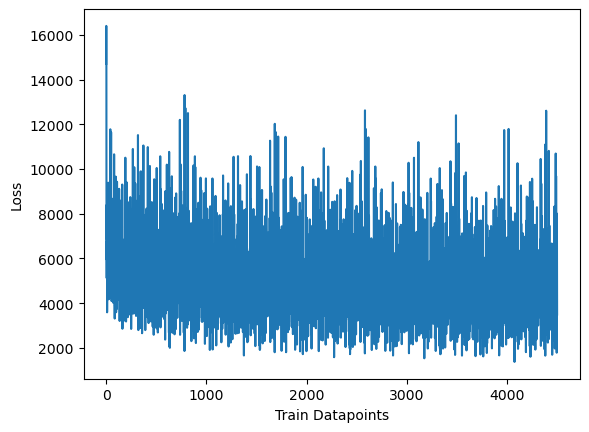

In [ ]:
with open(f'%s/loss.pickle'%(scratch_dir), 'rb') as f:
    lossl = pickle.load(f, encoding='bytes')

print(lossl[len(lossl) - 1])
plt.plot(lossl)
plt.xlabel('Train Datapoints')
plt.ylabel('Loss')
plt.show()

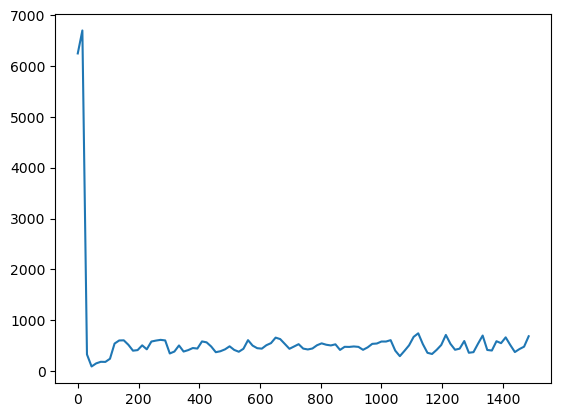

In [ ]:
# Flatten the list of arrays into a single array of spike times
with open(f'../work_dir/base_a0.07_pf0.8/results_1/1_spikes.pickle', 'rb') as f:
    spikes = pickle.load(f, encoding='bytes')
    
with open(f'../work_dir/base_a0.07_pf0.8/results_1/1_rates.pickle', 'rb') as f:
    rates = pickle.load(f, encoding='bytes')
    
all_spike_times = np.concatenate(spikes)

simtime = 1500
time_bins = np.linspace(0, simtime, num=100)

spike_counts, _ = np.histogram(all_spike_times, bins=time_bins)

plt.plot(time_bins[:-1], spike_counts)
plt.show()